## STUDY REGION

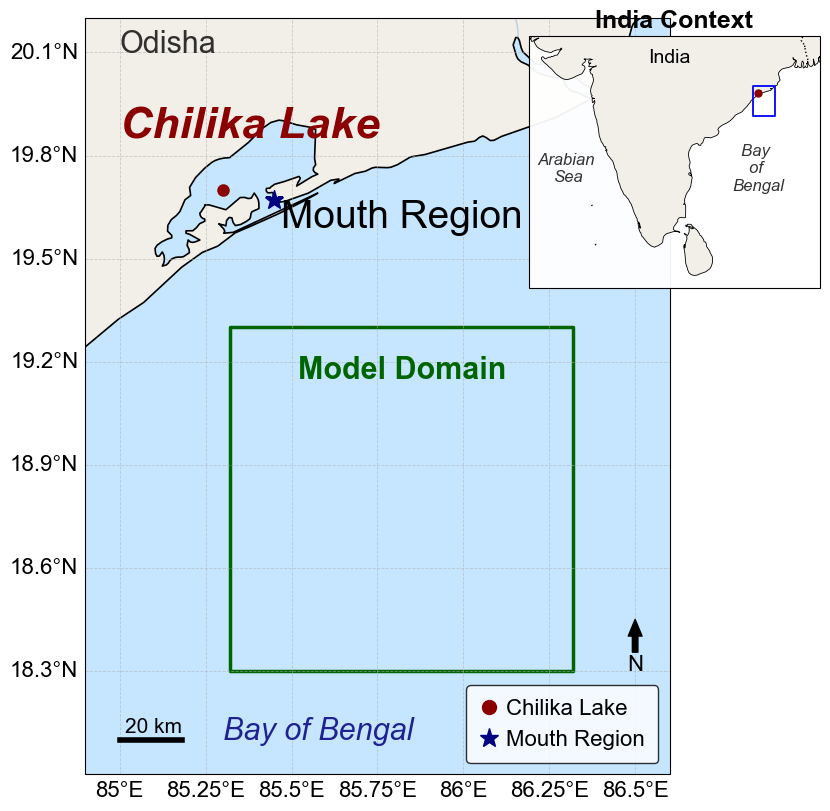

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import box
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'Arial'
# -----------------------------
# Coordinates
# -----------------------------
chilika_lat = 19.7
chilika_lon = 85.3

mouth_lat = 19.67
mouth_lon = 85.45

# Model domain (your study box)
LAT_MIN, LAT_MAX = 18.3, 19.3
LON_MIN, LON_MAX = 85.32, 86.32

model_box = box(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX)

# Adjust zoom to fully include model domain
zoom_extent = [84.9, 86.6, 18.0, 20.2]

# -----------------------------
# Create Figure
# -----------------------------
fig = plt.figure(figsize=(11, 9))

# =====================================================
# MAIN MAP (Chilika Focus)
# =====================================================
ax = fig.add_axes([0.06, 0.08, 0.82, 0.84],
                  projection=ccrs.PlateCarree())

ax.set_extent(zoom_extent)

# Land and Ocean styling
ax.add_feature(cfeature.LAND, facecolor='#f2efe9')
ax.add_feature(cfeature.OCEAN, facecolor='#c6e6ff')
ax.add_feature(cfeature.COASTLINE, linewidth=1.2)
ax.add_feature(cfeature.RIVERS, alpha=0.6)

# Gridlines
gl = ax.gridlines(draw_labels=True,
                  linewidth=0.6,
                  linestyle='--',
                  alpha=0.6)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}

# -----------------------------
# Mark Locations
# -----------------------------
ax.plot(chilika_lon, chilika_lat,
        marker='o', color='darkred', markersize=8,
        transform=ccrs.PlateCarree())

ax.text(chilika_lon - 0.3, chilika_lat + 0.15,
        "Chilika Lake",
        fontstyle='italic',
        fontsize=32,
        fontweight='bold',
        color='darkred',
        transform=ccrs.PlateCarree())

ax.plot(mouth_lon, mouth_lat,
        marker='*', color='navy', markersize=14,
        transform=ccrs.PlateCarree())

ax.text(mouth_lon + 0.02, mouth_lat - 0.08,
        "Mouth Region",
        fontsize=28,
        transform=ccrs.PlateCarree())

# -----------------------------
# Regional Labels
# -----------------------------
ax.text(85, 20.1,
        "Odisha",
        fontsize=22,
        alpha=0.8,
        transform=ccrs.PlateCarree())

ax.text(85.3, 18.1,
        "Bay of Bengal",
        fontsize=22,
        color='navy',
        fontstyle='italic',
        alpha=0.85,
        transform=ccrs.PlateCarree())

# -----------------------------
# Add Model Domain Box
# -----------------------------
ax.add_geometries([model_box],
                  crs=ccrs.PlateCarree(),
                  facecolor='none',
                  edgecolor='darkgreen',
                  linewidth=2.5)

ax.text(LON_MIN + 0.2, LAT_MAX - 0.15,
        "Model Domain",
        color='darkgreen',
        fontsize=22,
        fontweight='bold',
        transform=ccrs.PlateCarree())

# -----------------------------
# Scale Bar (20 km)
# -----------------------------
length_km = 20
deg_length = length_km / 111

ax.plot([85, 85 + deg_length],
        [18.1, 18.1],
        color='black', linewidth=4,
        transform=ccrs.PlateCarree())

ax.text(85 + deg_length/12, 18.12,
        "20 km",
        fontsize=15,
        transform=ccrs.PlateCarree())

# -----------------------------
# North Arrow
# -----------------------------
ax.annotate('N',
            xy=(86.5, 18.45),
            xytext=(86.5, 18.3),
            arrowprops=dict(facecolor='black',
                            width=4,
                            headwidth=10),
            ha='center',
            fontsize=16,
            transform=ccrs.PlateCarree())

# -----------------------------
# Legend (Use Same Markers as Map)
# -----------------------------

lake_handle = Line2D([0], [0],
                     marker='o',
                     linestyle='None',
                     markerfacecolor='darkred',
                     markeredgecolor='darkred',
                     markersize=10,
                     label='Chilika Lake')

mouth_handle = Line2D([0], [0],
                      marker='*',
                      linestyle='None',
                      markerfacecolor='navy',
                      markeredgecolor='navy',
                      markersize=14,
                      label='Mouth Region')

plt.legend(handles=[lake_handle, mouth_handle],
           loc='lower right',
           fontsize=16,
           frameon=True,         
           edgecolor='black',
           facecolor='white',
           handlelength=0.8,
           handletextpad=0.4,
           borderpad=0.6)


# =====================================================
# INDIA CONTEXT MAP (Smaller + Overlapping)
# =====================================================
ax_inset = fig.add_axes([0.60, 0.62, 0.28, 0.28],
                        projection=ccrs.PlateCarree())

# South India / NIO extent
ax_inset.set_extent([68, 90, 5, 24])

ax_inset.add_feature(cfeature.LAND, facecolor='#f2efe9')
ax_inset.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax_inset.add_feature(cfeature.BORDERS, linestyle=':')

# Add subtle white background for readability
ax_inset.patch.set_facecolor('white')
ax_inset.patch.set_alpha(0.95)

from matplotlib.lines import Line2D

# Mark Chilika
ax_inset.plot(chilika_lon, chilika_lat,
              marker='o',
              color='darkred',
              markersize=5,
              transform=ccrs.PlateCarree())

# Zoom box
rect = box(zoom_extent[0], zoom_extent[2],
           zoom_extent[1], zoom_extent[3])

ax_inset.add_geometries([rect],
                        crs=ccrs.PlateCarree(),
                        facecolor='none',
                        edgecolor='blue',
                        linewidth=1.3)

ax_inset.set_title("India Context",
                   fontweight='bold',
                   fontsize=18)

ax_inset.text(77, 22,
              "India",
              fontsize=14,
              transform=ccrs.PlateCarree())

ax_inset.text(71, 14,
              "Arabian \nSea",
              fontsize=12,
              fontstyle='italic',
                ha='center',
                va='center',
                alpha=0.8,
              transform=ccrs.PlateCarree())

ax_inset.text(85.3, 14,
              "Bay \nof \nBengal",
              fontsize=12,
                ha='center',
                va='center',
                alpha=0.8,
              fontstyle='italic',
              transform=ccrs.PlateCarree())

# -----------------------------
# Save High Resolution
# -----------------------------
plt.savefig("Chilika_Map.png",
            dpi=600,
            bbox_inches='tight')

plt.show()


### Final Test Metrics
### MSE: 0.1369
### RMSE: 0.3699
### MAE: 0.2586
### R²: 0.8617

# Actual vs. Predicted Value Comparison

In [1]:
import xarray as xr

# -------------------------------------------------
# PATHS
# -------------------------------------------------
TRUE_PATH = r"E:\ML Project\WOSC Project\WOSC Dynamic\Yaas_True_Actual.nc"
PRED_PATH = r"E:\ML Project\WOSC Project\WOSC Dynamic\Yaas_Predicted_Actual.nc"
PRE_PATH  = r"E:\ML Project\WOSC Project\WOSC Dynamic\Yaas_pre_mean.nc"

# -------------------------------------------------
# LOAD
# -------------------------------------------------
pred_ds = xr.open_dataset(PRED_PATH)
true_ds = xr.open_dataset(TRUE_PATH)
pre_ds  = xr.open_dataset(PRE_PATH)

# -------------------------------------------------
# SELECT SLICE
# -------------------------------------------------
t_idx = 4
d_idx = 10
lat_idx = 5
lon_idx = 5

var = "to"   # change to any variable 

pred_val = pred_ds[var].isel(
    time=t_idx,
    depth=d_idx,
    latitude=lat_idx,
    longitude=lon_idx
).values

true_val = true_ds[var].isel(
    time=t_idx,
    depth=d_idx,
    latitude=lat_idx,
    longitude=lon_idx
).values

pre_val = pre_ds[var].isel(
    time=t_idx,
    depth=d_idx,
    latitude=lat_idx,
    longitude=lon_idx
).values

# -------------------------------------------------
# PRINT COMPARISON
# -------------------------------------------------
print("Location:")
print("Time:", pred_ds.time.values[t_idx])
print("Depth:", pred_ds.depth.values[d_idx])
print("Lat:", pred_ds.latitude.values[lat_idx])
print("Lon:", pred_ds.longitude.values[lon_idx])

print("\nValues at this location:")
print("Predicted:", float(pred_val))
print("True     :", float(true_val))
print("Pre-Mean :", float(pre_val))
print("Error (Pred-True):", float(pred_val - true_val))

Location:
Time: 2021-05-27T00:00:00.000000000
Depth: 50.0
Lat: 18.9375
Lon: 86.0625

Values at this location:
Predicted: 28.085821826844107
True     : 27.245223036908868
Pre-Mean : 28.012900000000002
Error (Pred-True): 0.840598789935239


## Error Metrics (per variable)

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

# ==============================
# PATHS
# ==============================
TRUE_PATH = r"E:\ML Project\WOSC Project\WOSC Dynamic\Yaas_True_Actual.nc"
PRED_PATH = r"E:\ML Project\WOSC Project\WOSC Dynamic\Yaas_Predicted_Actual.nc"

vars_to_use = ["to", "so", "zo"]

# ==============================
# LOAD DATA
# ==============================
ds_true = xr.open_dataset(TRUE_PATH)
ds_pred = xr.open_dataset(PRED_PATH)

# ==============================
# FUNCTION TO COMPUTE METRICS
# ==============================
def compute_metrics(true, pred):
    # Flatten all dimensions to 1D
    y_true = true.values.flatten()
    y_pred = pred.values.flatten()

    # Remove NaNs
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    error = y_pred - y_true
    mse = np.mean(error**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(error))
    bias = np.mean(error)
    std_err = np.std(error)
    r2 = r2_score(y_true, y_pred)
    si = rmse / np.mean(np.abs(y_true))  # Scatter Index

    metrics = {
        "R2": r2,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "Bias": bias,
        "Std_Error": std_err,
        "Scatter_Index": si
    }

    return metrics

# ==============================
# COMPUTE METRICS PER VARIABLE
# ==============================
results = []

for var in vars_to_use:
    metrics = compute_metrics(ds_true[var], ds_pred[var])
    metrics["Variable"] = var
    results.append(metrics)

# Convert to DataFrame for easy viewing
df_metrics = pd.DataFrame(results)
df_metrics = df_metrics.set_index("Variable")

print(df_metrics)

                R2       MSE      RMSE       MAE      Bias  Std_Error  \
Variable                                                                
to        0.824199  0.830824  0.911496  0.627985  0.131577   0.901949   
so        0.713448  0.186019  0.431299  0.283941  0.114175   0.415912   
zo        0.904137  0.004997  0.070689  0.046828  0.018063   0.068343   

          Scatter_Index  
Variable                 
to             0.032217  
so             0.012934  
zo             0.086955  


## Error metrics (All variables)

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

# ==============================
# PATHS
# ==============================
TRUE_PATH = r"E:\ML Project\WOSC Project\WOSC Dynamic\Yaas_True_Actual.nc"
PRED_PATH = r"E:\ML Project\WOSC Project\WOSC Dynamic\Yaas_Predicted_Actual.nc"

vars_to_use = ["to", "so", "zo"]

# ==============================
# LOAD DATA
# ==============================
ds_true = xr.open_dataset(TRUE_PATH)
ds_pred = xr.open_dataset(PRED_PATH)

# ==============================
# FUNCTION TO COMPUTE METRICS
# ==============================
def compute_metrics(true, pred):
    # Flatten all dimensions to 1D 
    y_true = true.flatten()
    y_pred = pred.flatten()

    # Remove NaNs
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    error = y_pred - y_true
    mse = np.mean(error**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(error))
    bias = np.mean(error)
    std_err = np.std(error)
    r2 = r2_score(y_true, y_pred)
    si = rmse / np.mean(np.abs(y_true))  # Scatter Index

    metrics = {
        "R2": r2,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "Bias": bias,
        "Std_Error": std_err,
        "Scatter_Index": si
    }

    return metrics

# ==============================
# COMBINE ALL VARIABLES
# ==============================
true_all = xr.concat([ds_true[var] for var in vars_to_use], dim="all_vars")
pred_all = xr.concat([ds_pred[var] for var in vars_to_use], dim="all_vars")

# ==============================
# COMPUTE METRICS OVER TOTAL DATA
# ==============================
total_metrics = compute_metrics(true_all.values, pred_all.values)
df_metrics_total = pd.DataFrame([total_metrics], index=["All_Variables"])
print(df_metrics_total)

                     R2       MSE      RMSE       MAE      Bias  Std_Error  \
All_Variables  0.998348  0.340613  0.583621  0.319585  0.087938   0.576958   

               Scatter_Index  
All_Variables       0.028036  


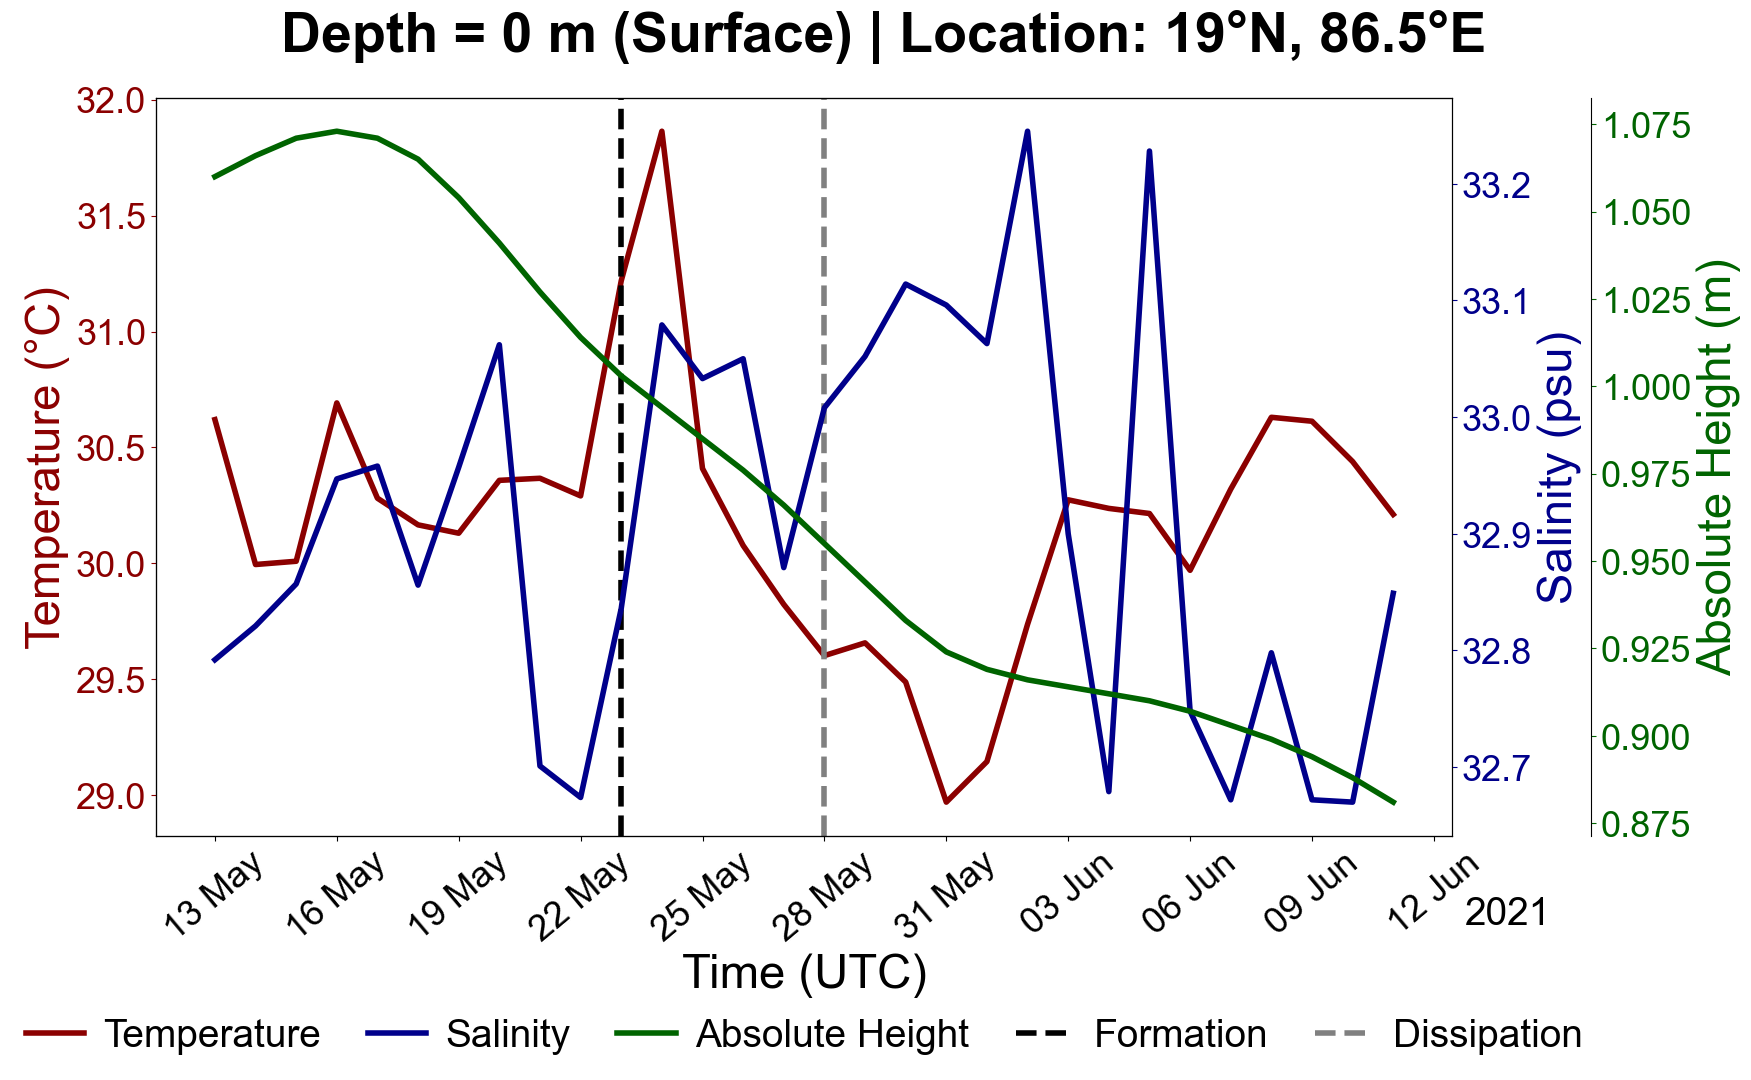

In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Put all file paths in a list
file_paths = [
    r"E:\ML Project\WOSC Project\EarthFormer\Data\amphan_2020-05-06_to_2020-06-04.nc",
    r"E:\ML Project\WOSC Project\EarthFormer\Data\asani_2022-04-27_to_2022-05-26.nc",
    r"E:\ML Project\WOSC Project\EarthFormer\Data\dana_2024-10-12_to_2024-11-10.nc",
    r"E:\ML Project\WOSC Project\EarthFormer\Data\fani_2019-04-16_to_2019-05-15.nc",
    r"E:\ML Project\WOSC Project\EarthFormer\Data\gulab_2021-09-14_to_2021-10-13.nc",
    r"E:\ML Project\WOSC Project\EarthFormer\Data\hudhud_2014-09-27_to_2014-10-26.nc",
    r"E:\ML Project\WOSC Project\EarthFormer\Data\phailin_2013-09-24_to_2013-10-23.nc",
    r"E:\ML Project\WOSC Project\EarthFormer\Data\titli_2018-09-28_to_2018-10-27.nc",
    r"E:\ML Project\WOSC Project\EarthFormer\Data\yaas_2021-05-13_to_2021-06-11.nc" 
]

# Empty list to store datasets
datasets = []

# Loop through files and open them
for path in file_paths:
    ds = xr.open_dataset(path)
    datasets.append(ds)
    
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 28,
    'axes.titlesize': 40,
    'axes.labelsize': 34,
    'xtick.labelsize': 26,
    'ytick.labelsize': 26,
    'legend.fontsize': 28
})

CYCLONES = ["Amphan","Asani","Dana","Fani",
            "Gulab","Hudhud","Phailin","Titli","Yaas"]

FORMATION_DATES = {
    "Yaas": "2021-05-23"
}

DISSIPATION_DATES = {
    "Yaas": "2021-05-28"
}

# ---------------- Select Only Fani ----------------
yaas_index = 8
ds = datasets[yaas_index]
cyclone_name = "Yaas"
temp = ds["to"].sel(depth=0, latitude=19, longitude=86.5, method="nearest")
sal  = ds["so"].sel(depth=0, latitude=19, longitude=86.5, method="nearest")
height = ds["zo"].sel(depth=0, latitude=19, longitude=86.5, method="nearest")

time = temp.time.values
formation_date = pd.to_datetime(FORMATION_DATES["Yaas"])
dissipation_date = pd.to_datetime(DISSIPATION_DATES["Yaas"])

# ---------------- Figure ----------------
fig, ax1 = plt.subplots(figsize=(18, 12))

ax2 = ax1.twinx()
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 100))

# ---------------- Plot Lines ----------------
line1 = ax1.plot(time, temp.values, color="darkred", linewidth=4, label="Temperature")
line2 = ax2.plot(time, sal.values, color="darkblue", linewidth=4, label="Salinity")
line3 = ax3.plot(time, height.values, color="darkgreen", linewidth=4, label="Absolute Height")

# ---------------- Y Labels ----------------
ax1.set_ylabel("Temperature (°C)", color="darkred")
ax2.set_ylabel("Salinity (psu)", color="darkblue")
ax3.set_ylabel("Absolute Height (m)", color="darkgreen")

ax1.tick_params(axis='y', colors="darkred")
ax2.tick_params(axis='y', colors="darkblue")
ax3.tick_params(axis='y', colors="darkgreen")

# ---------------- Formation & Dissipation Lines ----------------
f_line = ax1.axvline(formation_date, color="black", linestyle="--", linewidth=4, label="Formation")
d_line = ax1.axvline(dissipation_date, color="gray", linestyle="--", linewidth=4, label="Dissipation")

# ---------------- X Axis ----------------
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))  # Remove year
ax1.tick_params(axis='x', rotation=40)
ax1.set_xlabel("Time (UTC)")

# Add year only once at end of axis
year_text = pd.to_datetime(time[-1]).strftime('%Y')
ax1.text(
    1.01, -0.12, year_text,
    transform=ax1.transAxes,
    fontsize=28,
)

# ---------------- Horizontal Legend at Bottom ----------------
lines = line1 + line2 + line3 + [f_line, d_line]
labels = [l.get_label() for l in lines]

ax1.legend(
    lines, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.2),
    ncol=5,
    frameon=False,
    columnspacing=1.2,     # reduces space between columns (default ~2.0)
    handletextpad=0.5,     # space between line and text
    handlelength=1.5       # length of legend line
)


# ---------------- Title ----------------
fig.suptitle(
    "Depth = 0 m (Surface) | Location: 19°N, 86.5°E",
    fontsize=40,
    fontweight="bold",
    y=0.95   # controls vertical position (smaller = lower)
)

# ---------------- Save ----------------
plt.tight_layout()
plt.savefig("Yaas_response.png", dpi=600, bbox_inches='tight')
plt.show()


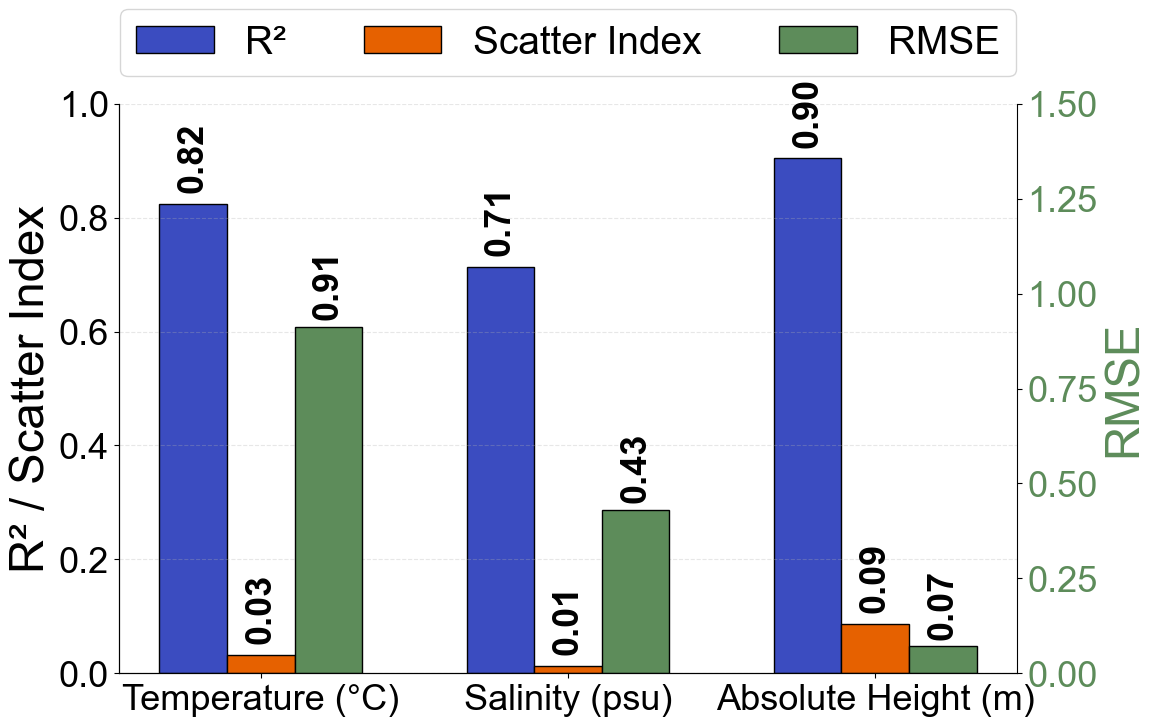

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# GLOBAL FONT SETTINGS (Poster Optimized)
# --------------------------------------------------
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 28,
    'axes.titlesize': 40,
    'axes.labelsize': 34,
    'xtick.labelsize': 26,
    'ytick.labelsize': 26,
    'legend.fontsize': 28
})

# Data
variables = ['Temperature (°C)', 'Salinity (psu)', 'Absolute Height (m)']

r2 = [0.824199, 0.713448, 0.904137]
scatter_index = [0.032217, 0.012934, 0.086955]
rmse = [0.911496, 0.431299, 0.070689]

x = np.arange(len(variables))
width = 0.22

fig, ax1 = plt.subplots(figsize=(12,8))

# Professional colors
c_r2   = '#3B4CC0'
c_si   = '#E66100'
c_rmse = '#5D8C5A'

# -----------------------
# Primary Axis (R² + SI)
# -----------------------
bars1 = ax1.bar(x - width, r2, width,
                label='R²',
                color=c_r2,
                edgecolor='black',
                linewidth=1)

bars2 = ax1.bar(x, scatter_index, width,
                label='Scatter Index',
                color=c_si,
                edgecolor='black',
                linewidth=1)

ax1.set_ylabel('R² / Scatter Index')
ax1.set_ylim(0, 1)

# -----------------------
# Secondary Axis (RMSE)
# -----------------------
ax2 = ax1.twinx()

bars3 = ax2.bar(x + width, rmse, width,
                label='RMSE',
                color=c_rmse,
                edgecolor='black',
                linewidth=1)

ax2.set_ylabel('RMSE', color=c_rmse)
ax2.tick_params(axis='y', labelcolor=c_rmse)
ax2.set_ylim(0, 1.5)

# -----------------------
# Clean Look
# -----------------------
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax1.set_xticks(x)
ax1.set_xticklabels(variables)

ax1.grid(axis='y', linestyle='--', alpha=0.3)

# -----------------------
# Write Values on Bars
# -----------------------
def add_labels(bars, axis):
    for bar in bars:
        height = bar.get_height()
        axis.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.02,
            f'{height:.2f}',        # 2 decimal places
            ha='center',
            va='bottom',
            rotation=90,           # vertical text
            fontsize=26,
            fontweight='bold'
        )

add_labels(bars1, ax1)
add_labels(bars2, ax1)
add_labels(bars3, ax2)

# -----------------------
# Legend ABOVE plot
# -----------------------
handles = [bars1, bars2, bars3]
labels = ['R²', 'Scatter Index', 'RMSE']

ax1.legend(handles, labels,
           loc='upper center',
           bbox_to_anchor=(0.5, 1.2),
           ncol=3,
           frameon=True)

plt.tight_layout()

plt.savefig("Performance.png",
            dpi=600,
            bbox_inches='tight')

plt.show()


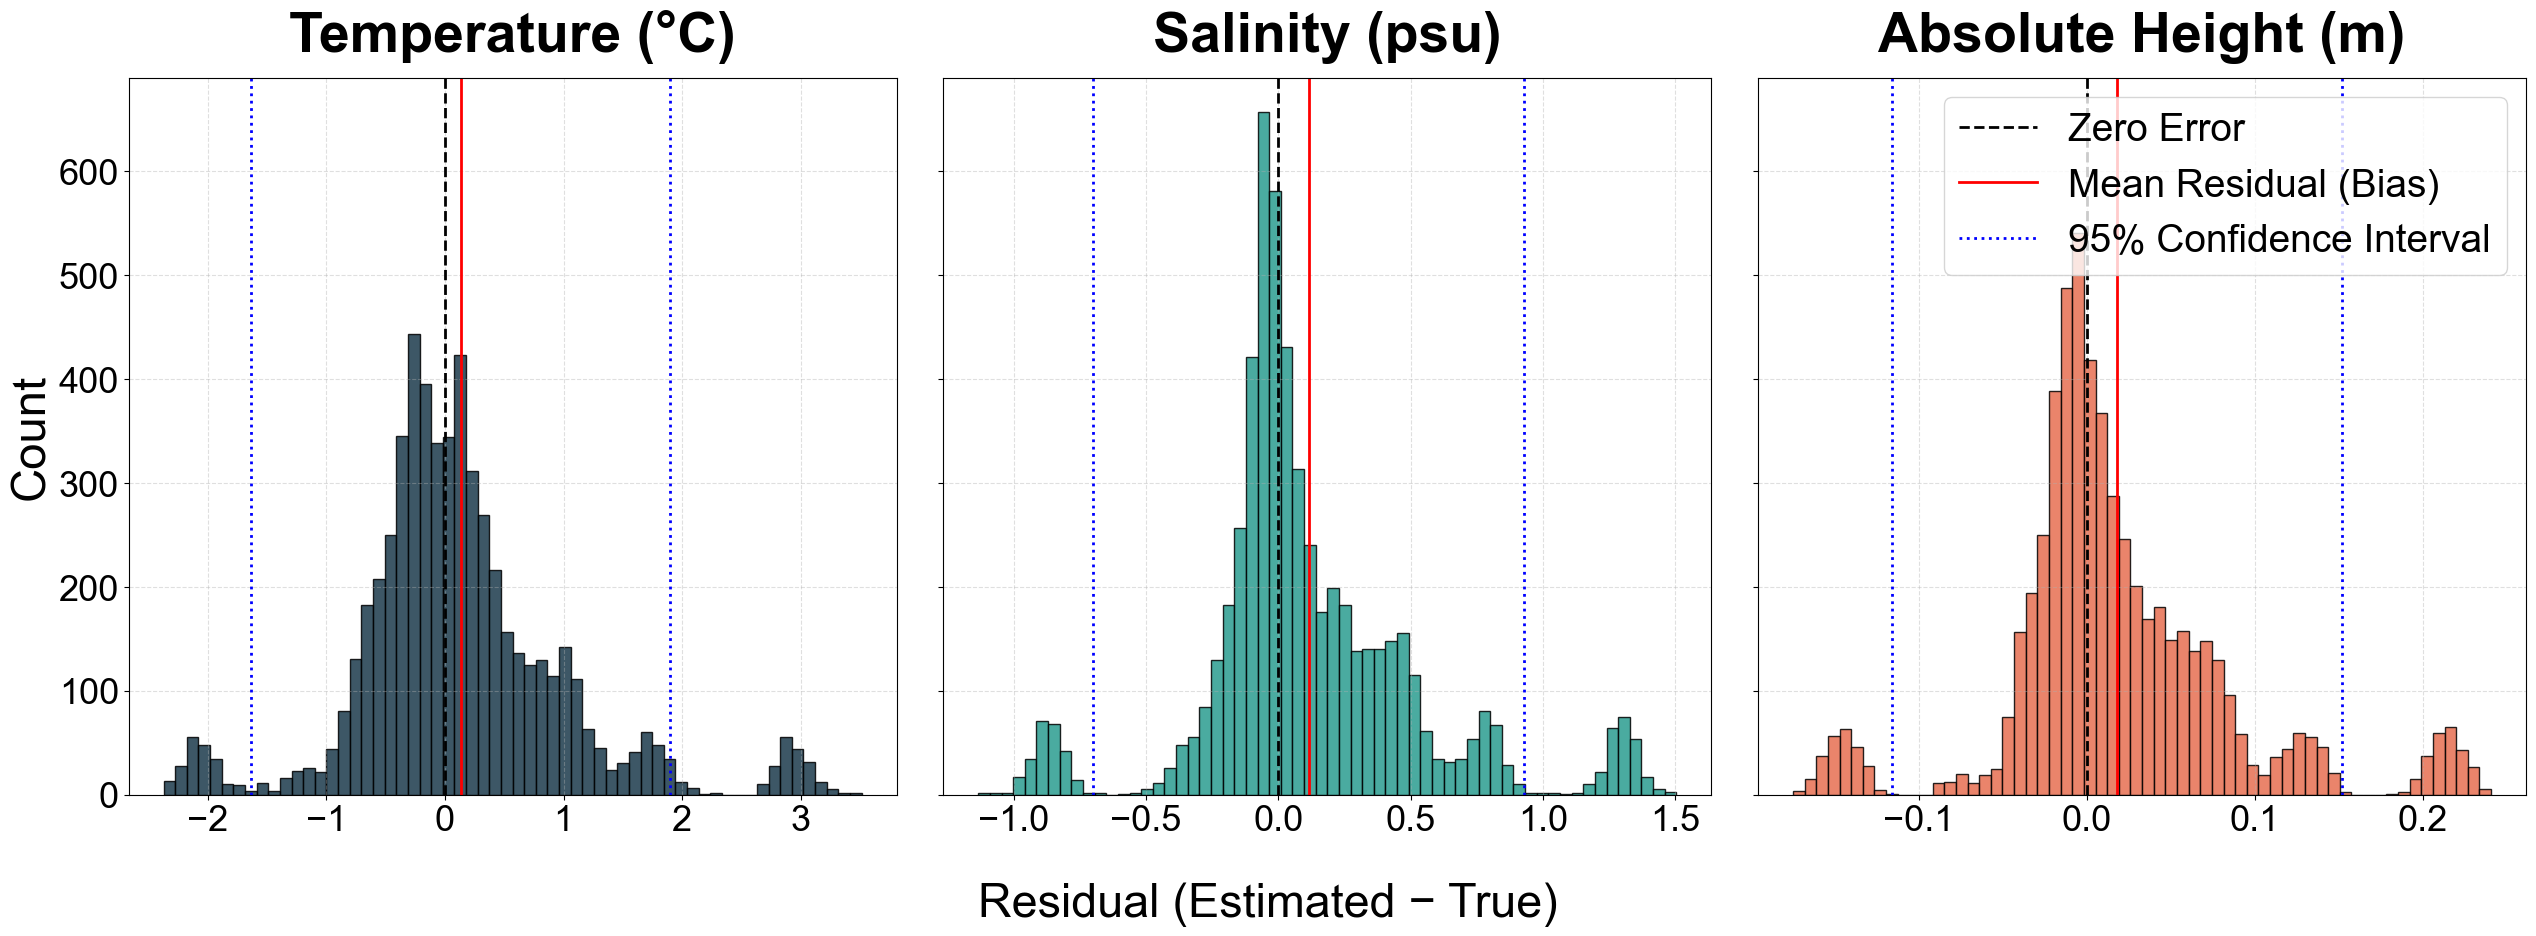

In [38]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# GLOBAL POSTER FONT SETTINGS
# =====================================================
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 28,
    'axes.titlesize': 40,
    'axes.labelsize': 34,
    'xtick.labelsize': 26,
    'ytick.labelsize': 26,
    'legend.fontsize': 28
})

# =====================================================
# PATHS
# =====================================================
TRUE_PATH = r"E:\ML Project\WOSC Project\WOSC Dynamic\Yaas_True_Actual.nc"
PRED_PATH = r"E:\ML Project\WOSC Project\WOSC Dynamic\Yaas_Predicted_Actual.nc"

vars_to_use = ["to", "so", "zo"]

var_labels = {
    "to": "Temperature (°C)",
    "so": "Salinity (psu)",
    "zo": "Absolute Height (m)"
}

# =====================================================
# LOAD DATA
# =====================================================
ds_true = xr.open_dataset(TRUE_PATH)
ds_pred = xr.open_dataset(PRED_PATH)

# =====================================================
# CREATE FIGURE
# =====================================================
fig, axes = plt.subplots(1, 3, figsize=(26,10), sharey=True)

colors = ['#1B3A4B', '#2A9D8F', '#E76F51']

for i, var in enumerate(vars_to_use):

    true_vals = ds_true[var].values.reshape(-1)
    pred_vals = ds_pred[var].values.reshape(-1)

    residuals = pred_vals - true_vals
    mean_residual = np.mean(residuals)
    std_residual = np.std(residuals)

    lower_95 = mean_residual - 1.96 * std_residual
    upper_95 = mean_residual + 1.96 * std_residual

    # Histogram
    axes[i].hist(residuals,
                 bins=60,
                 color=colors[i],
                 edgecolor='black',
                 alpha=0.85)

    # Zero error line
    axes[i].axvline(0,
                    linestyle='--',
                    color='black',
                    linewidth=2,
                    label='Zero Error')

    # Mean residual (Bias)
    axes[i].axvline(mean_residual,
                    linestyle='-',
                    color='red',
                    linewidth=2,
                    label='Mean Residual (Bias)')

    # 95% confidence interval lines
    axes[i].axvline(lower_95,
                    linestyle=':',
                    color='blue',
                    linewidth=2,
                    label='95% Confidence Interval')

    axes[i].axvline(upper_95,
                    linestyle=':',
                    color='blue',
                    linewidth=2)

    axes[i].set_title(var_labels[var],
                      fontweight='bold',
                      y=1.025)

    axes[i].grid(True, linestyle='--', alpha=0.4)

# Common labels
fig.supxlabel("Residual (Estimated − True)", y=0.04)
axes[0].set_ylabel("Count")

# Add legend only once
axes[2].legend(loc='upper right', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig("Residual.png", dpi=600, bbox_inches='tight')
plt.show()


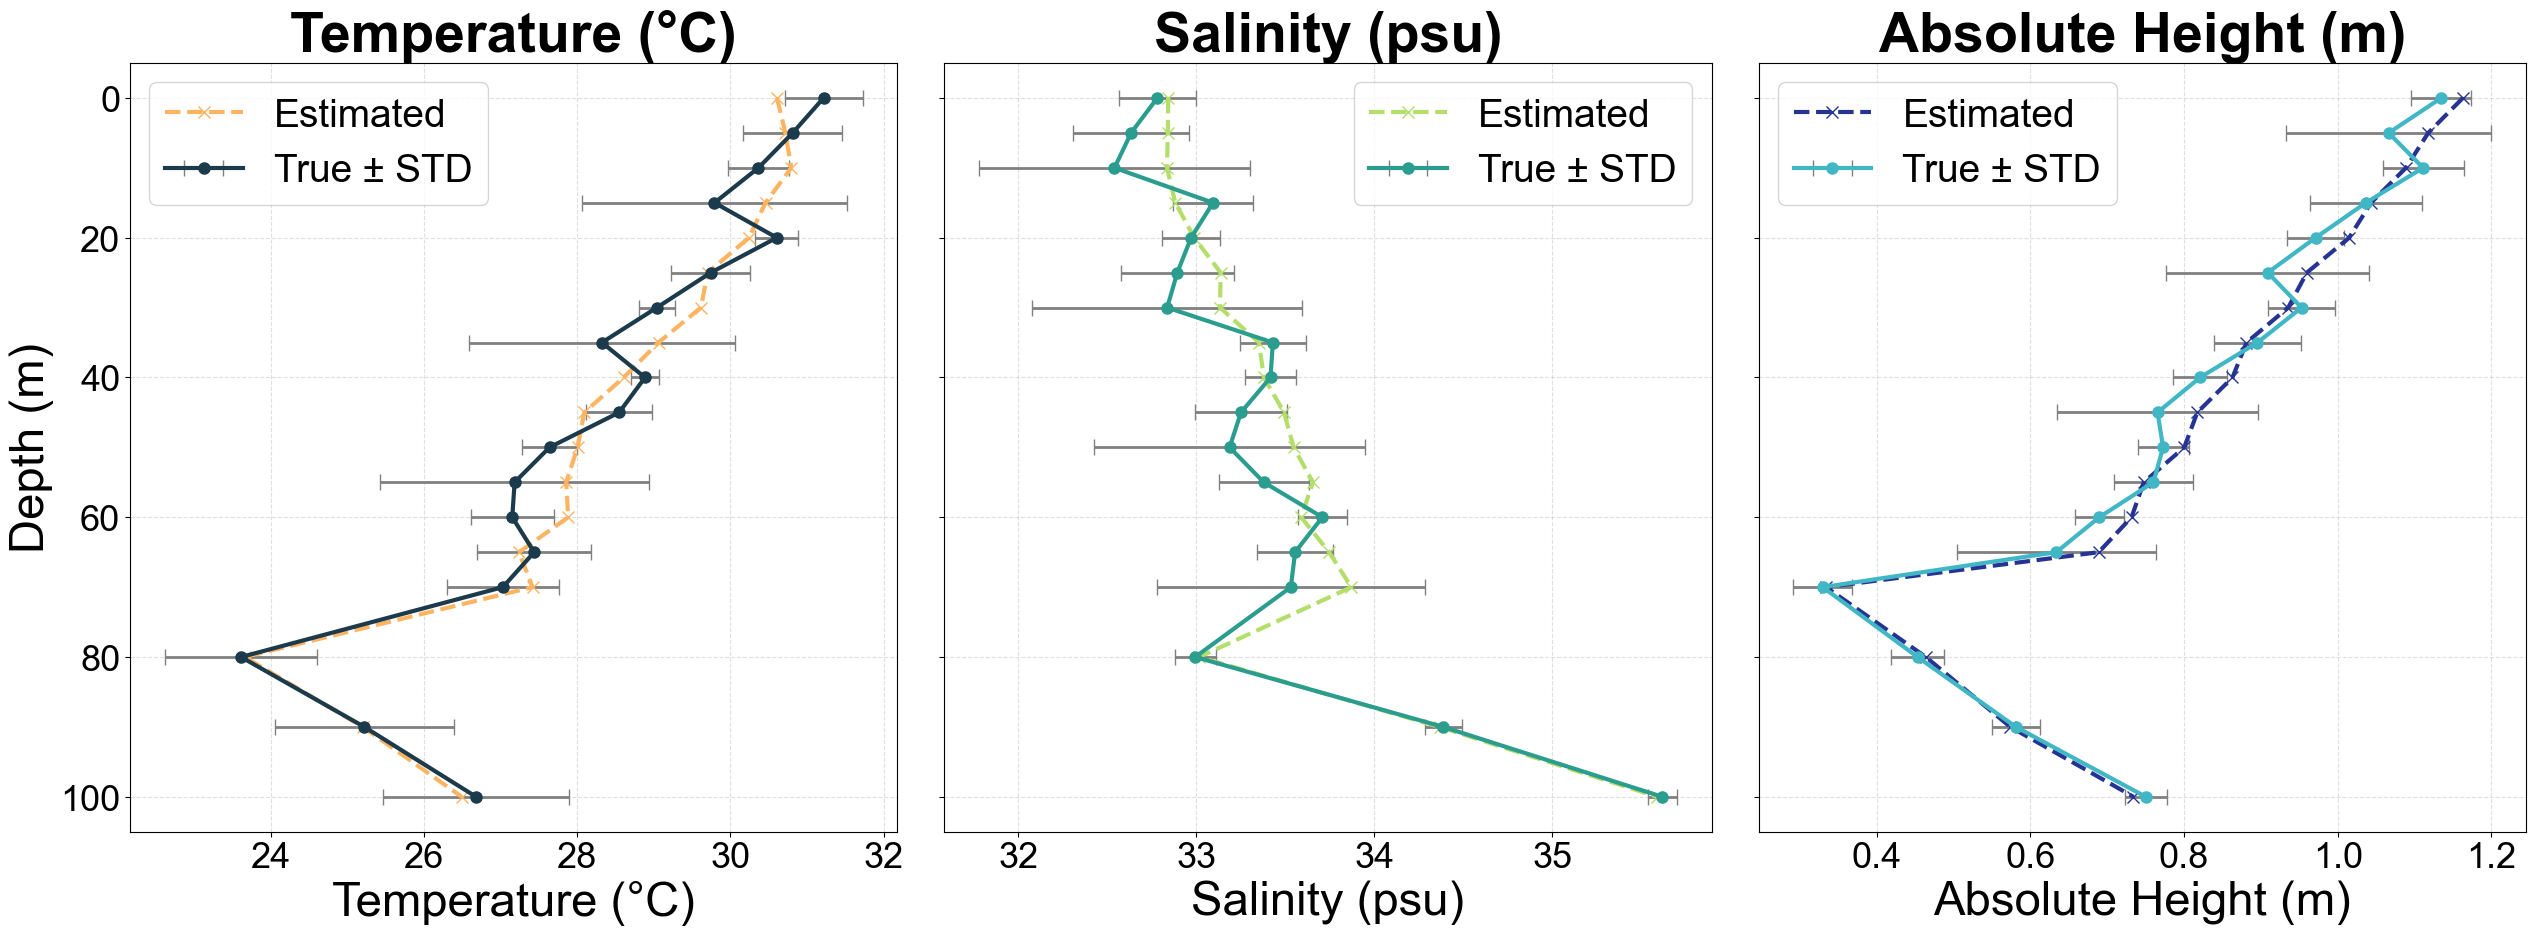

In [10]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# GLOBAL POSTER FONT SETTINGS
# =====================================================
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 28,
    'axes.titlesize': 40,
    'axes.labelsize': 34,
    'xtick.labelsize': 26,
    'ytick.labelsize': 26,
    'legend.fontsize': 28
})

# ==============================
# PATHS
# ==============================
TRUE_PATH = r"E:\ML Project\WOSC Project\WOSC Dynamic\Yaas_True_Actual.nc"
PRED_PATH = r"E:\ML Project\WOSC Project\WOSC Dynamic\Yaas_Predicted_Actual.nc"

vars_to_use = ["to", "so", "zo"]
var_labels = {
    "to": "Temperature (°C)",
    "so": "Salinity (psu)",
    "zo": "Absolute Height (m)"
}

colors_true = ['#1B3A4B', '#2A9D8F', '#41b6c4']
colors_pred = ['#FDB462', '#B3DE69', '#253494']

# ==============================
# LOAD DATA
# ==============================
ds_true = xr.open_dataset(TRUE_PATH)
ds_pred = xr.open_dataset(PRED_PATH)

depths = ds_true.depth.values

# ==============================
# CREATE FIGURE (Larger for Poster)
# ==============================
fig, axes = plt.subplots(1, 3, figsize=(26,10), sharey=True)
plt.subplots_adjust(wspace=0.30)

for i, var in enumerate(vars_to_use):

    true_profile = ds_true[var].mean(dim=["time","latitude","longitude"]).values
    true_std = ds_true[var].std(dim=["time","latitude","longitude"]).values
    pred_profile = ds_pred[var].mean(dim=["time","latitude","longitude"]).values

    ax = axes[i]

    # True with error bars
    ax.errorbar(
        true_profile, depths, xerr=true_std,
        label="True ± STD",
        fmt='-o',
        color=colors_true[i],
        ecolor='gray',
        elinewidth=2,
        capsize=6,
        markersize=8,
        linewidth=3
    )

    # Predicted curve
    ax.plot(pred_profile, depths,
            label="Estimated",
            linestyle='--',
            color=colors_pred[i],
            marker='x',
            markersize=8,
            linewidth=3)

    ax.set_title(var_labels[var], fontweight='bold')
    ax.set_xlabel(var_labels[var])
    ax.grid(True, linestyle='--', alpha=0.4)

# Y-axis common
axes[0].set_ylabel("Depth (m)")
axes[0].invert_yaxis()

# Legends (only once per subplot for clarity)
for ax in axes:
    ax.legend(loc='best')

plt.tight_layout()
plt.savefig("Depth_Profile.png", dpi=600, bbox_inches='tight')
plt.show()


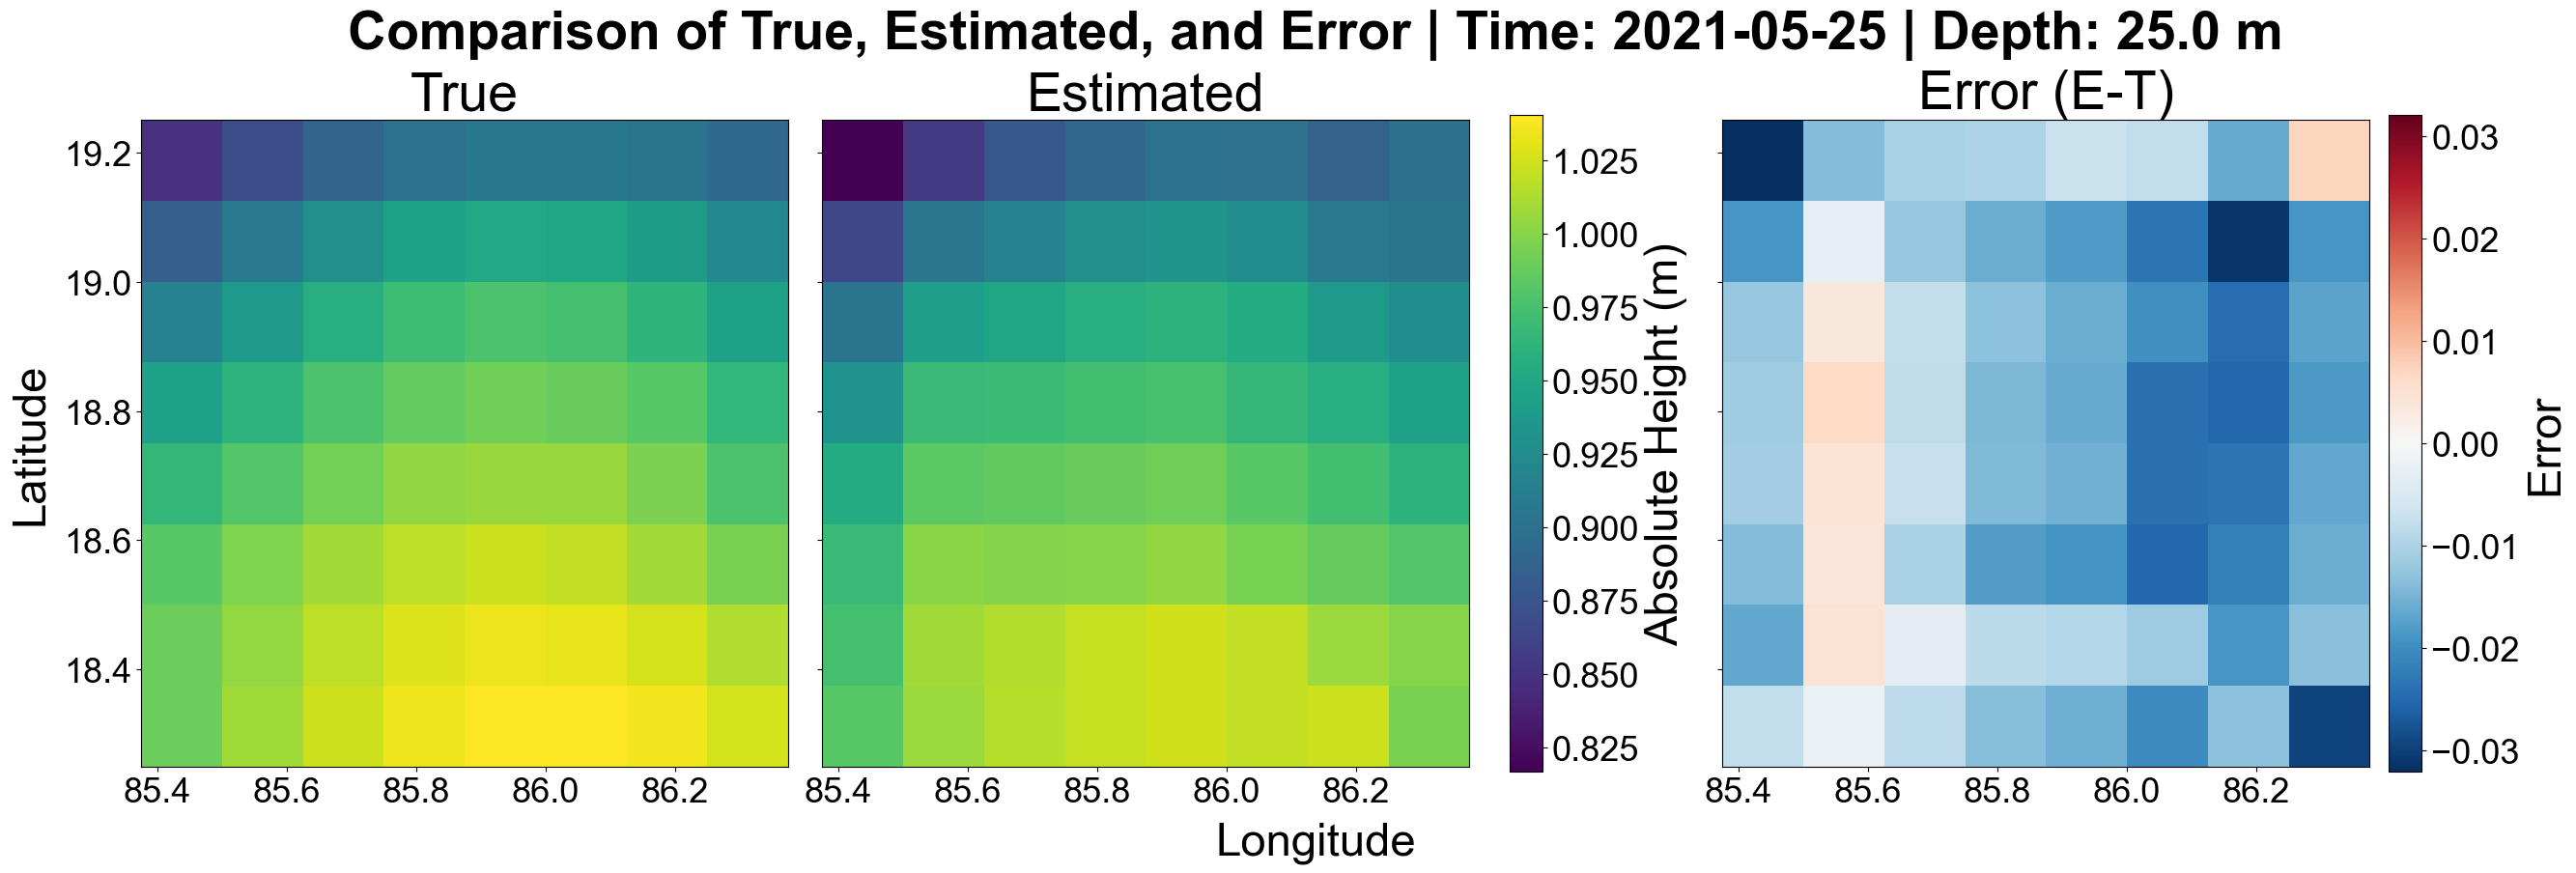

In [7]:
import xarray as xr 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# ==============================
# Use Arial font
# ==============================
plt.rcParams['font.family'] = 'Arial'

# ==============================
# PATHS
# ==============================
TRUE_PATH = r"E:\ML Project\WOSC Project\WOSC Dynamic\Yaas_True_Actual.nc"
PRED_PATH = r"E:\ML Project\WOSC Project\WOSC Dynamic\Yaas_Predicted_Actual.nc"

# ==============================
# LOAD DATA
# ==============================
ds_true = xr.open_dataset(TRUE_PATH)
ds_pred = xr.open_dataset(PRED_PATH)

# Choose timestep and depth
t = 2      # time index
d = 5      # depth index

# Variable
var = "zo"

# ==============================
# SLICES
# ==============================
true_slice = ds_true[var].isel(time=t, depth=d)
pred_slice = ds_pred[var].isel(time=t, depth=d)
diff = pred_slice - true_slice

# ==============================
# FIGURE SETUP
# ==============================
fig, axes = plt.subplots(1, 3, figsize=(26,10), constrained_layout=True)

# Poster-friendly font sizes
fontsize_title = 40
fontsize_label = 34
fontsize_ticks = 26

# ----------------- COMMON COLOR SCALE -----------------
vmin = float(min(true_slice.min(), pred_slice.min()))
vmax = float(max(true_slice.max(), pred_slice.max()))
cmap_tp = 'viridis'

# ----------------- TRUE -----------------
im0 = axes[0].pcolormesh(
    ds_true.longitude,
    ds_true.latitude,
    true_slice,
    shading='auto',
    cmap=cmap_tp,
    vmin=vmin, vmax=vmax
)
axes[0].set_title("True", fontsize=fontsize_title)
axes[0].tick_params(axis='both', labelsize=fontsize_ticks)
axes[0].set_aspect('equal')

# ----------------- PREDICTED -----------------
im1 = axes[1].pcolormesh(
    ds_pred.longitude,
    ds_pred.latitude,
    pred_slice,
    shading='auto',
    cmap=cmap_tp,
    vmin=vmin, vmax=vmax
)
axes[1].set_title("Estimated", fontsize=fontsize_title)
axes[1].tick_params(axis='both', labelsize=fontsize_ticks)
axes[1].set_aspect('equal')
axes[1].tick_params(labelleft=False)

# ----------------- ERROR -----------------
abs_max = float(np.abs(diff).max())
norm = TwoSlopeNorm(vmin=-abs_max, vcenter=0.0, vmax=abs_max)

im2 = axes[2].pcolormesh(
    ds_true.longitude,
    ds_true.latitude,
    diff,
    shading='auto',
    cmap='RdBu_r',
    norm=norm
)
axes[2].set_title("Error (E-T)", fontsize=fontsize_title)
axes[2].tick_params(axis='both', labelsize=fontsize_ticks)
axes[2].set_aspect('equal')
axes[2].tick_params(labelleft=False)

# ----------------- COMMON LATITUDE AND LONGITUDE -----------------
fig.supxlabel("Longitude", fontsize=fontsize_label, y=0.065)  # move down below x-ticks
fig.supylabel("Latitude", fontsize=fontsize_label, x=-0.02)   # move left of y-ticks


# ----------------- COLORBARS -----------------
# -----------------------------------
# COLORBAR SIZE CONTROLS
# -----------------------------------
cbar_fraction = 0.06   # thickness (increase = thicker)
cbar_pad = 0.03        # distance from axes
cbar_aspect = 20     # lower = thicker & shorter
cbar_shrink = 0.685      # 1.0 = full height

# True / Pred combined colorbar 
cbar_tp = fig.colorbar(im0, ax=axes[:2], 
                       fraction=cbar_fraction, 
                       pad=cbar_pad, 
                       aspect=cbar_aspect, 
                       shrink=cbar_shrink) 
cbar_tp.set_label("Absolute Height (m)", fontsize=fontsize_label) 
cbar_tp.ax.tick_params(labelsize=fontsize_ticks)

# Error colorbar
cbar_err = fig.colorbar(
    im2,
    ax=axes[2],
    fraction=cbar_fraction,
    pad=cbar_pad,
    aspect=cbar_aspect,
    shrink=cbar_shrink
)
cbar_err.set_label("Error", fontsize=fontsize_label)
cbar_err.ax.tick_params(labelsize=fontsize_ticks)


# ----------------- SUPTITLE -----------------
fig.suptitle(
    f"Comparison of True, Estimated, and Error | Time: {str(ds_true.time.values[t])[:10]} | Depth: {float(ds_true.depth.values[d])} m",
    fontsize=40, fontweight= 'bold', y=0.95
)

# ==============================
# SAVE & SHOW
# ==============================
# Save figure without cutting off anything
plt.savefig(
    "Absolute_Height_Comparison.png",
    dpi=600,
    bbox_inches='tight',  # ensures everything, including manual labels, is included
    pad_inches=0.1        # small padding around figure
)
plt.show()
